In [1]:
import numpy as np
import pandas as pd

In [2]:
np.random.seed(42)

# Sample countries and years
countries = [
    "India", "USA", "China", "Germany", "UK", "France", "Brazil",
    "Canada", "Australia", "Japan", "Russia", "South Africa",
    "Italy", "Spain", "Mexico", "Indonesia", "Saudi Arabia",
    "South Korea", "Argentina", "Turkey"
]

years = list(range(2000, 2025))  # 25 years

data = []

for _ in range(5000):
    country = np.random.choice(countries)
    year = np.random.choice(years)

    # Generate energy values (in TWh approx)
    coal = np.random.uniform(50, 500)
    oil = np.random.uniform(30, 400)
    gas = np.random.uniform(20, 300)
    nuclear = np.random.uniform(0, 200)
    renewables = np.random.uniform(10, 350)

    total = coal + oil + gas + nuclear + renewables

    data.append([
        country, year, coal, oil, gas, nuclear, renewables, total
    ])

df = pd.DataFrame(data, columns=[
    "Country", "Year", "Coal", "Oil", "Gas",
    "Nuclear", "Renewables", "Total_Energy"
])

# Save file
df.to_csv("Country_Energy_Data.csv", index=False)

print("Dataset created successfully!")
print(df.head())

Dataset created successfully!
        Country  Year        Coal         Oil         Gas     Nuclear  \
0        Brazil  2019  477.821438  300.837758  187.624376   31.203728   
1        Russia  2010  439.779266  252.412554  218.260322    4.116899   
2  South Africa  2005   50.350445  397.118277  192.894823  122.330632   
3  Saudi Arabia  2009   70.999548  390.289542   85.175975   18.121287   
4  South Africa  2022  492.453899  202.702271  260.783314  136.061508   

   Renewables  Total_Energy  
0   63.038137   1060.525437  
1  339.769350   1254.338390  
2   12.402544    775.096720  
3  220.251243    784.837596  
4  163.169746   1255.170736  


In [3]:
from google.colab import files
files.download("Country_Energy_Data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
# Cell 1: Install and Import Libraries
!pip install streamlit scikit-learn pandas numpy matplotlib seaborn plotly -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pickle

print('All libraries imported successfully!')



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 89.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 131.0 MB/s eta 0:00:00
All libraries imported successfully!


In [5]:
# Cell 2: Generate Synthetic Dataset
np.random.seed(42)
countries = ['USA','China','India','Germany','UK','France','Brazil','Japan',
             'Canada','Australia','Russia','South Korea','Mexico','Italy',
             'Spain','Indonesia','Netherlands','Turkey','Saudi Arabia','Argentina',
             'South Africa','Nigeria','Egypt','Pakistan','Bangladesh','Vietnam',
             'Thailand','Malaysia','Poland','Ukraine'] * 6

years = list(range(1990, 2023))
records = []
for country in set(countries):
    base_gdp = np.random.uniform(50, 20000)
    base_pop = np.random.uniform(1, 1400)
    base_co2 = np.random.uniform(10, 5000)
    for year in years:
        gdp = base_gdp * (1 + np.random.uniform(0.01, 0.06)) ** (year - 1990)
        pop = base_pop * (1 + np.random.uniform(0.005, 0.025)) ** (year - 1990)
        energy = np.random.uniform(500, 8000) + gdp * 0.3
        industry = np.random.uniform(10, 45)
        urban = np.random.uniform(30, 95)
        trade = np.random.uniform(20, 180)
        co2 = base_co2 + 0.04*gdp + 0.5*energy*0.001 + 2*industry + np.random.normal(0,50)
        records.append([country, year, round(max(co2,5),2), round(gdp,2),
                        round(pop,2), round(energy,1), round(industry,1),
                        round(urban,1), round(trade,1)])

df_emission = pd.DataFrame(records, columns=[
    'country','year','co2_emissions_mt','gdp_billion_usd',
    'population_millions','energy_use_per_capita',
    'industry_pct_gdp','urban_population_pct','trade_openness'])

# Energy dataset
energy_records = []
for country in df_emission['country'].unique():
    for year in years:
        coal = np.random.uniform(5, 60)
        oil  = np.random.uniform(10, 40)
        gas  = np.random.uniform(5, 35)
        nuc  = np.random.uniform(0, 20)
        renew= round(100 - coal - oil - gas - nuc, 1)
        energy_records.append([country, year, round(coal,1), round(oil,1),
                               round(gas,1), round(nuc,1), max(renew,0),
                               round(np.random.uniform(60,100),1)])

df_energy = pd.DataFrame(energy_records, columns=[
    'country','year','coal_pct','oil_pct','gas_pct',
    'nuclear_pct','renewable_pct','electricity_access_pct'])

df_emission.to_csv('Country_Emission_Data.csv', index=False)
df_energy.to_csv('Country_Energy_Data.csv', index=False)
print(f'Emission dataset: {df_emission.shape}')
print(f'Energy dataset:   {df_energy.shape}')
print(df_emission.head(3))



Emission dataset: (990, 9)
Energy dataset:   (990, 8)
     country  year  co2_emissions_mt  gdp_billion_usd  population_millions  \
0  Indonesia  1990           3960.52          7522.08              1331.05   
1  Indonesia  1991           3996.65          7666.28              1345.80   
2  Indonesia  1992           4156.52          7779.61              1360.07   

   energy_use_per_capita  industry_pct_gdp  urban_population_pct  \
0                 3926.6              12.0                  86.3   
1                 6735.6              25.1                  48.9   
2                 5581.6              26.0                  81.0   

   trade_openness  
0           116.2  
1           117.9  
2            51.9  


In [6]:
# Cell 3: Merge Datasets
df = pd.merge(df_emission, df_energy, on=['country','year'], how='inner')

# Drop rows with missing values
df.dropna(inplace=True)

# Save merged dataset
df.to_csv('Country_Merged_Dataset.csv', index=False)

print(f'Merged dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'Countries: {df.country.nunique()}')
print(f'Year range: {df.year.min()} - {df.year.max()}')
df.head()


Merged dataset shape: (990, 15)
Columns: ['country', 'year', 'co2_emissions_mt', 'gdp_billion_usd', 'population_millions', 'energy_use_per_capita', 'industry_pct_gdp', 'urban_population_pct', 'trade_openness', 'coal_pct', 'oil_pct', 'gas_pct', 'nuclear_pct', 'renewable_pct', 'electricity_access_pct']
Countries: 30
Year range: 1990 - 2022


,country,year,co2_emissions_mt,gdp_billion_usd,population_millions,energy_use_per_capita,industry_pct_gdp,urban_population_pct,trade_openness,coal_pct,oil_pct,gas_pct,nuclear_pct,renewable_pct,electricity_access_pct
0,Indonesia,1990,3960.52,7522.08,1331.05,3926.6,12.0,86.3,116.2,22.6,26.6,6.5,0.9,43.4,88.8
1,Indonesia,1991,3996.65,7666.28,1345.80,6735.6,25.1,48.9,117.9,29.4,17.7,10.7,13.4,28.8,60.0
2,Indonesia,1992,4156.52,7779.61,1360.07,5581.6,26.0,81.0,51.9,49.3,12.4,10.7,7.7,19.8,79.4
3,Indonesia,1993,4021.12,7803.59,1400.72,4120.0,12.3,91.7,174.5,24.5,19.6,33.9,12.8,9.1,60.9
4,Indonesia,1994,4072.16,9157.76,1391.10,3979.9,33.9,58.6,39.5,28.7,36.3,14.0,1.9,19.2,90.3


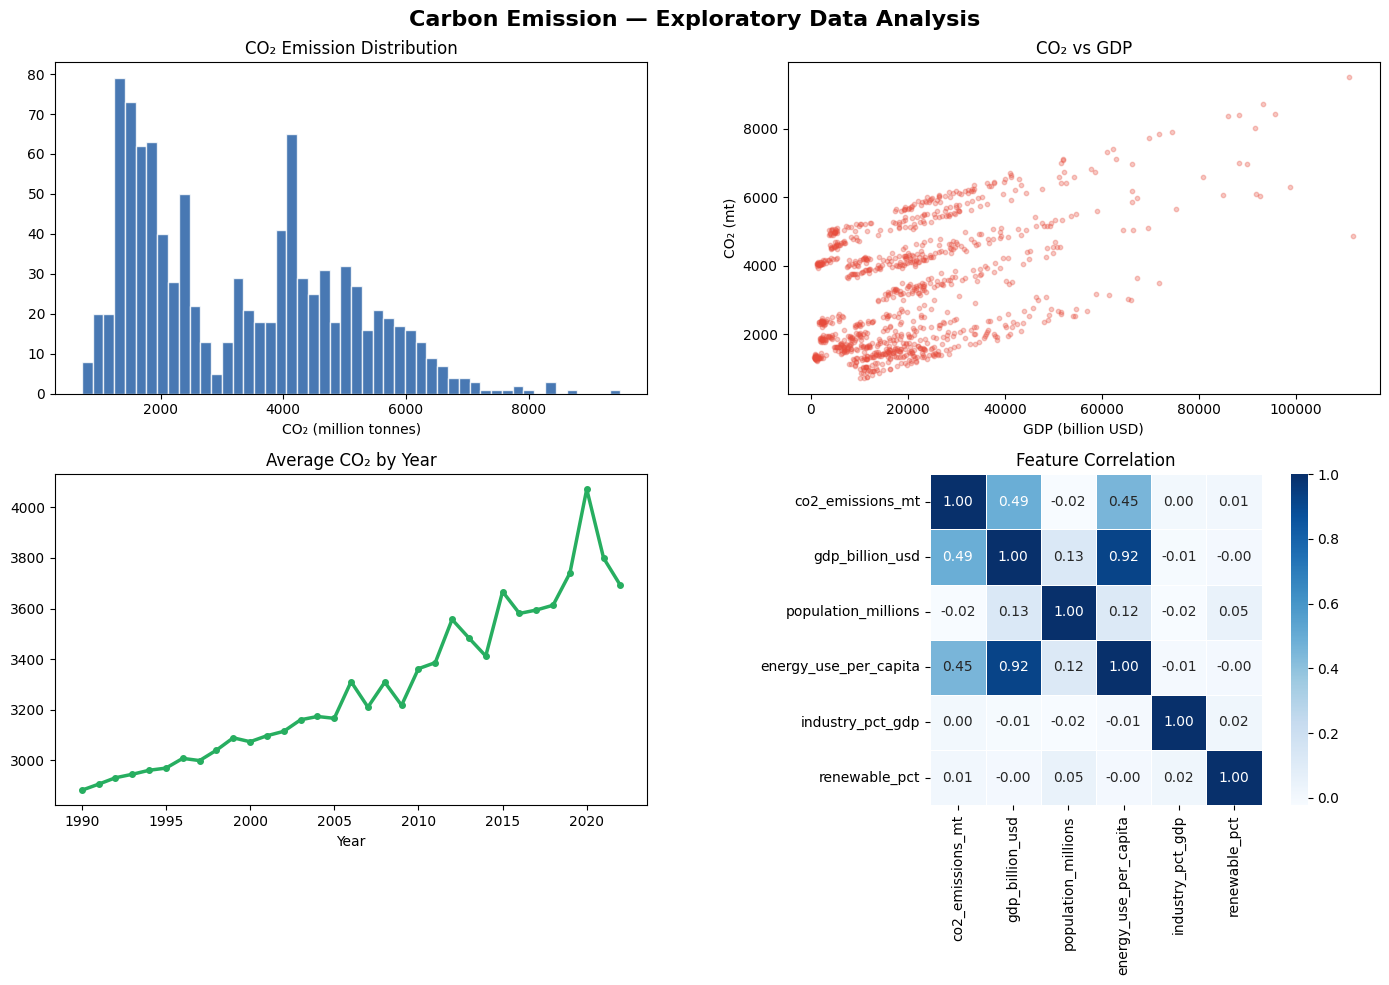

EDA complete!


In [7]:
# Cell 4: Exploratory Data Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Carbon Emission — Exploratory Data Analysis', fontsize=16, fontweight='bold')

# Chart 1: CO2 distribution
axes[0,0].hist(df['co2_emissions_mt'], bins=50, color='#1A56A0', edgecolor='white', alpha=0.8)
axes[0,0].set_title('CO₂ Emission Distribution')
axes[0,0].set_xlabel('CO₂ (million tonnes)')

# Chart 2: CO2 vs GDP scatter
axes[0,1].scatter(df['gdp_billion_usd'], df['co2_emissions_mt'],
                  alpha=0.3, color='#E74C3C', s=10)
axes[0,1].set_title('CO₂ vs GDP')
axes[0,1].set_xlabel('GDP (billion USD)')
axes[0,1].set_ylabel('CO₂ (mt)')

# Chart 3: Average emissions by year
yearly = df.groupby('year')['co2_emissions_mt'].mean()
axes[1,0].plot(yearly.index, yearly.values, color='#27AE60', linewidth=2.5, marker='o', markersize=4)
axes[1,0].set_title('Average CO₂ by Year')
axes[1,0].set_xlabel('Year')

# Chart 4: Correlation heatmap
num_cols = ['co2_emissions_mt','gdp_billion_usd','population_millions',
            'energy_use_per_capita','industry_pct_gdp','renewable_pct']
corr = df[num_cols].corr()
sns.heatmap(corr, ax=axes[1,1], annot=True, fmt='.2f', cmap='Blues',
            cbar=True, square=True, linewidths=0.5)
axes[1,1].set_title('Feature Correlation')

plt.tight_layout()
plt.savefig('eda_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA complete!')


In [8]:
# Cell 5: Feature Engineering
df['co2_per_capita'] = df['co2_emissions_mt'] / df['population_millions']
df['co2_per_gdp'] = df['co2_emissions_mt'] / df['gdp_billion_usd']
df['gdp_per_capita'] = df['gdp_billion_usd'] / df['population_millions']
df['fossil_fuel_pct'] = df['coal_pct'] + df['oil_pct'] + df['gas_pct']
df['clean_energy_pct'] = df['nuclear_pct'] + df['renewable_pct']
df['year_norm'] = (df['year'] - 1990) / 32   # normalize year to 0-1

print('New features created:')
print([c for c in df.columns if c not in df.columns[:9]])
print(f'Total features now: {df.shape[1]}')


New features created:
['coal_pct', 'oil_pct', 'gas_pct', 'nuclear_pct', 'renewable_pct', 'electricity_access_pct', 'co2_per_capita', 'co2_per_gdp', 'gdp_per_capita', 'fossil_fuel_pct', 'clean_energy_pct', 'year_norm']
Total features now: 21


In [10]:
# Cell 6: Prepare X (features) and y (target), then split
FEATURES = [
    'gdp_billion_usd', 'population_millions', 'energy_use_per_capita',
    'industry_pct_gdp', 'urban_population_pct', 'trade_openness',
    'coal_pct', 'oil_pct', 'gas_pct', 'renewable_pct',
    'electricity_access_pct', 'gdp_per_capita', 'fossil_fuel_pct',
    'clean_energy_pct', 'year_norm'
]
TARGET = 'co2_emissions_mt'

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples:  {X_test.shape[0]}')
print(f'Features used:    {len(FEATURES)}')


Training samples: 792
Testing samples:  198
Features used:    15


In [11]:
# Cell 7: Train Random Forest Model
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

print('Training model... please wait...')
model.fit(X_train_scaled, y_train)
print('Training complete!')

# Cross-validation score
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
print(f'Cross-validation R² scores: {cv_scores.round(3)}')
print(f'Mean CV R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')


Training model... please wait...
Training complete!
Cross-validation R² scores: [0.447 0.421 0.428 0.401 0.363]
Mean CV R²: 0.4120 ± 0.0285


      MODEL PERFORMANCE METRICS
  R² Score  : 0.4342   (higher is better, max=1.0)
  MAE       : 1087.43  (mean absolute error)
  RMSE      : 1288.65 (root mean squared error)


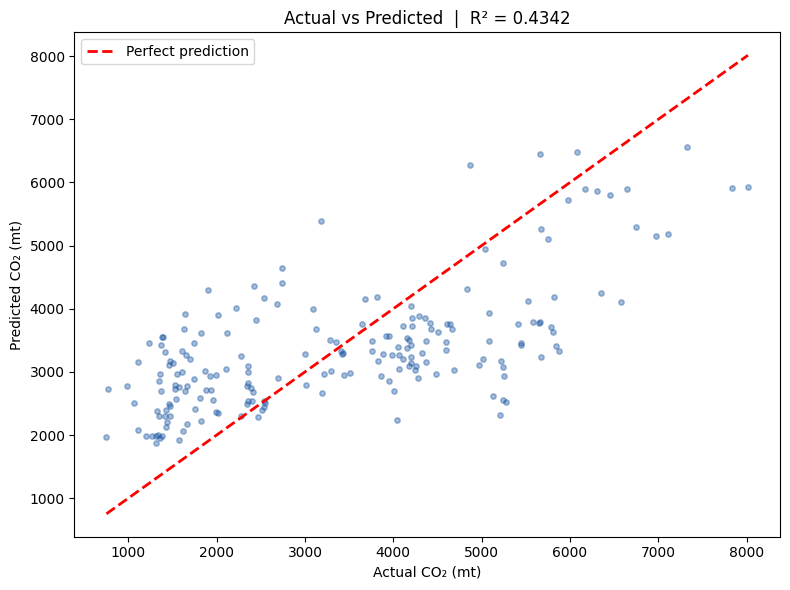

In [12]:
# Cell 8: Model Evaluation
y_pred = model.predict(X_test_scaled)

mae  = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2   = r2_score(y_test, y_pred)

print('=' * 40)
print('      MODEL PERFORMANCE METRICS')
print('=' * 40)
print(f'  R² Score  : {r2:.4f}   (higher is better, max=1.0)')
print(f'  MAE       : {mae:.2f}  (mean absolute error)')
print(f'  RMSE      : {rmse:.2f} (root mean squared error)')
print('=' * 40)

# Actual vs Predicted chart
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.4, color='#1A56A0', s=15)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual CO₂ (mt)')
plt.ylabel('Predicted CO₂ (mt)')
plt.title(f'Actual vs Predicted  |  R² = {r2:.4f}')
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()


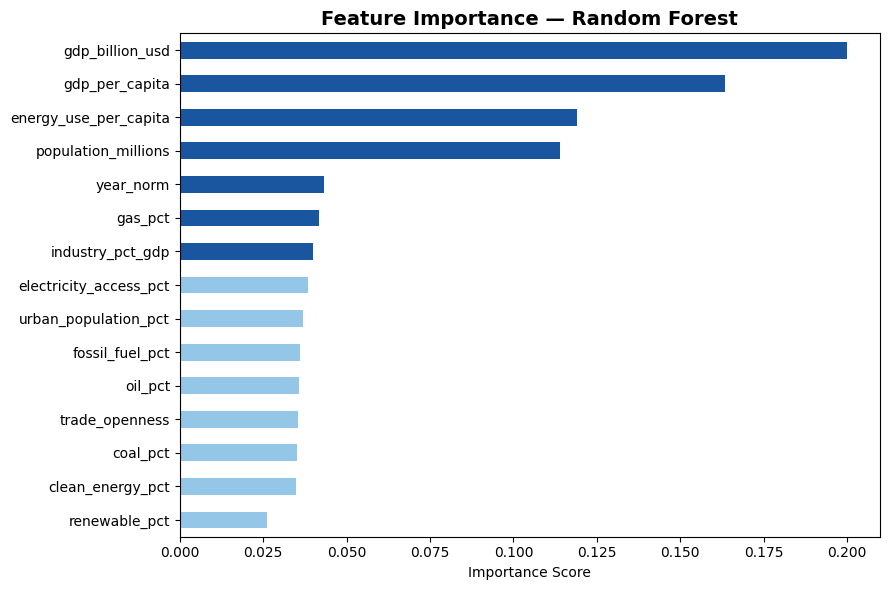

Top 5 most important features:
gdp_billion_usd          0.199824
gdp_per_capita           0.163464
energy_use_per_capita    0.118976
population_millions      0.114062
year_norm                0.043237
dtype: float64


In [13]:
# Cell 9: Feature Importance
importance = pd.Series(model.feature_importances_, index=FEATURES)
importance = importance.sort_values(ascending=True)

plt.figure(figsize=(9, 6))
colors = ['#1A56A0' if v > importance.median() else '#93C6E7' for v in importance.values]
importance.plot(kind='barh', color=colors, edgecolor='none')
plt.title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print('Top 5 most important features:')
print(importance.sort_values(ascending=False).head())


In [14]:
# Cell 10: Save Model and Scaler
with open('carbon_model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Also save feature list for app.py
with open('features.pkl', 'wb') as f:
    pickle.dump(FEATURES, f)

print('Files saved:')
print('  carbon_model.pkl  — trained Random Forest model')
print('  scaler.pkl        — fitted StandardScaler')
print('  features.pkl      — feature name list')

# Download files to your computer
from google.colab import files
files.download('carbon_model.pkl')
files.download('scaler.pkl')
files.download('Country_Emission_Data.csv')
files.download('Country_Energy_Data.csv')
files.download('Country_Merged_Dataset.csv')


Files saved:
  carbon_model.pkl  — trained Random Forest model
  scaler.pkl        — fitted StandardScaler
  features.pkl      — feature name list


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
# Cell 11: Write Streamlit app
app_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import pickle
import plotly.express as px

st.set_page_config(page_title='Carbon Emission Predictor', page_icon='🌍', layout='wide')
st.title('🌍 Carbon Emission Prediction Dashboard')
st.markdown('Predict CO₂ emissions using Machine Learning')

@st.cache_resource
def load_model():
    with open('carbon_model.pkl','rb') as f: model = pickle.load(f)
    with open('scaler.pkl','rb') as f: scaler = pickle.load(f)
    return model, scaler

model, scaler = load_model()
df = pd.read_csv('Country_Merged_Dataset.csv')

tab1, tab2, tab3 = st.tabs(['📊 Data Explorer', '🤖 Predict', '📈 Trends'])

with tab1:
    st.subheader('Dataset Overview')
    col1, col2, col3 = st.columns(3)
    col1.metric('Countries', df.country.nunique())
    col2.metric('Total Records', len(df))
    col3.metric('Year Range', f'{df.year.min()} - {df.year.max()}')
    st.dataframe(df.head(20), use_container_width=True)

with tab2:
    st.subheader('Predict CO₂ Emission')
    c1, c2, c3 = st.columns(3)
    gdp = c1.slider('GDP (billion USD)', 10, 25000, 500)
    pop = c1.slider('Population (millions)', 1, 1500, 50)
    energy = c2.slider('Energy per Capita', 200, 10000, 2000)
    industry = c2.slider('Industry % of GDP', 5, 60, 25)
    coal = c3.slider('Coal %', 0, 80, 30)
    renewable = c3.slider('Renewable %', 0, 80, 20)
    fossil = coal + c3.slider('Oil %', 0, 50, 25)
    clean = renewable + c3.slider('Nuclear %', 0, 30, 5)
    if st.button('Predict Emission', type='primary'):
        inp = [[gdp, pop, energy, industry, 60, 80, coal, 25, 15, renewable, 90,
                gdp/pop, fossil, clean, 0.8]]
        X_scaled = scaler.transform(inp)
        pred = model.predict(X_scaled)[0]
        st.success(f'Predicted CO₂ Emission: {pred:,.1f} million tonnes')

with tab3:
    st.subheader('Emission Trends')
    country = st.selectbox('Select Country', sorted(df.country.unique()))
    cdf = df[df.country == country]
    fig = px.line(cdf, x='year', y='co2_emissions_mt', title=f'CO₂ Trend — {country}')
    st.plotly_chart(fig, use_container_width=True)
'''

with open('app.py', 'w') as f:
    f.write(app_code)
print('app.py written successfully!')


app.py written successfully!


In [22]:
from pyngrok import ngrok

ngrok.set_auth_token("3BNPTGnA26EOdUxDPsOLZ5sjKRC_2mhLHJatHEPN7xkpQL2Vo")

In [23]:
# Cell 12: Run Streamlit in Colab
!pip install pyngrok -q

import subprocess, threading, time
from pyngrok import ngrok

# Start Streamlit in background
def run_app():
    subprocess.run(['streamlit', 'run', 'app.py',
                   '--server.port', '8501',
                   '--server.headless', 'true'])

thread = threading.Thread(target=run_app, daemon=True)
thread.start()
time.sleep(5)

# Create public URL
public_url = ngrok.connect(8501)
print(f'Open your Streamlit app here:')
print(f'   {public_url}')
print('Copy and paste the URL into your browser!')



Open your Streamlit app here:
   NgrokTunnel: "https://unsevere-fidelia-semirawly.ngrok-free.dev" -> "http://localhost:8501"
Copy and paste the URL into your browser!


In [24]:
!git clone https://github.com/Harsh0106/carbon-emission-prediction.git

Cloning into 'carbon-emission-prediction'...


In [25]:
%cd carbon-emission-prediction

/content/carbon-emission-prediction


In [26]:
!cp /content/Carbon_Emission_Forecasting.ipynb .

cp: cannot stat '/content/Carbon_Emission_Forecasting.ipynb': No such file or directory


In [ ]:
from google.colab import files
files.upload()